# NMC data QC 

# Import Required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import anndata as ad
import seaborn as sns
import scanpy as sc
import yaml
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Required Inputs

In [2]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
metadata_dir = Path(config['metadata_dir'])
preprocessed_dir = Path(config['preprocessed_dir'])

# make a roi list of directories in preprocessed_dir that are not .DS_Store
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']


# Extract patients metadata and export it to the new format

In [3]:
patients_metadata = pd.read_excel(metadata_dir / 'patient_metadata.xlsx')
patients_metadata["outcome"] = patients_metadata["outcome"].str.extract('(\d+)').astype(int)
#remove excluded rois
patients_metadata = patients_metadata.loc[~patients_metadata["rois"].isna()]
#add a new column if the  "outcome" column is greater than 9
patients_metadata["outcome_group"] = np.where(patients_metadata["outcome"] > 6, "long_term survival", "short_term survival")
patients_metadata["rois"] = patients_metadata["rois"].astype(str)
patients_metadata['rois'] = patients_metadata['rois'].str.split(r'\+ ')
patients_metadata = patients_metadata.explode('rois', ignore_index=True)
patients_metadata['rois'] = patients_metadata['rois'].str.strip()
for i in range(len(patients_metadata)):
    if patients_metadata['rois'][i].find('-') != -1:
        new_patient = patients_metadata['rois'][i].split('-')
        new_patient = np.array(range(int(new_patient[0]), int(new_patient[1])+1))
        patients_metadata['rois'][i] = new_patient

patients_metadata = patients_metadata.explode('rois', ignore_index=True)
patients_metadata["rois"] = patients_metadata["rois"].astype(str)
patients_metadata["exp_name"] = "Run" +  patients_metadata['run'].astype(int).astype(str) + '_ROI' + patients_metadata['rois'].astype(str)
patients_metadata.to_csv(metadata_dir / 'new_patients_metadata.csv', index=False)

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_2836/757644536.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  patients_metadata['rois'][i] = new_patient
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_2836/7576445

In [4]:
patients_metadata

,patient_ID,age at diagnosis,sex,site,outcome,therapy systemic,therapy local,disease stage,run,rois,outcome_group,exp_name
0,NMC_1,9,m,submandibular gland right,10,CTx,RTx,NaN,145,1,long_term survival,Run145_ROI1
1,NMC_1,9,m,submandibular gland right,10,CTx,RTx,NaN,145,3,long_term survival,Run145_ROI3
2,NMC_2,6,m,lung hilus right,3,CTx,RTx,NaN,141,1,short_term survival,Run141_ROI1
3,NMC_4,14,f,"lung, pleura, mediastinum",4,CTx,RTx,T4N3M1,145,9,short_term survival,Run145_ROI9
4,NMC_5,10,m,nasal sinus right,9,CTx,RTx,T3N2M1,145,10,long_term survival,Run145_ROI10
5,NMC_5,10,m,nasal sinus right,9,CTx,RTx,T3N2M1,145,11,long_term survival,Run145_ROI11
6,NMC_5,10,m,nasal sinus right,9,CTx,RTx,T3N2M1,145,12,long_term survival,Run145_ROI12
7,NMC_6,23,m,right lung + lymph nodes,7,CTx,RTx,T2N2M0,103,5,long_term survival,Run103_ROI5
8,NMC_6,23,m,right lung + lymph nodes,7,CTx,RTx,T2N2M0,103,6,long_term survival,Run103_ROI6
9,NMC_7,9,m,"lung, mediastinum",9,CTx,RTx,T4N1M1,145,13,long_term survival,Run145_ROI13


## Compare number of ROIS based on the survival time

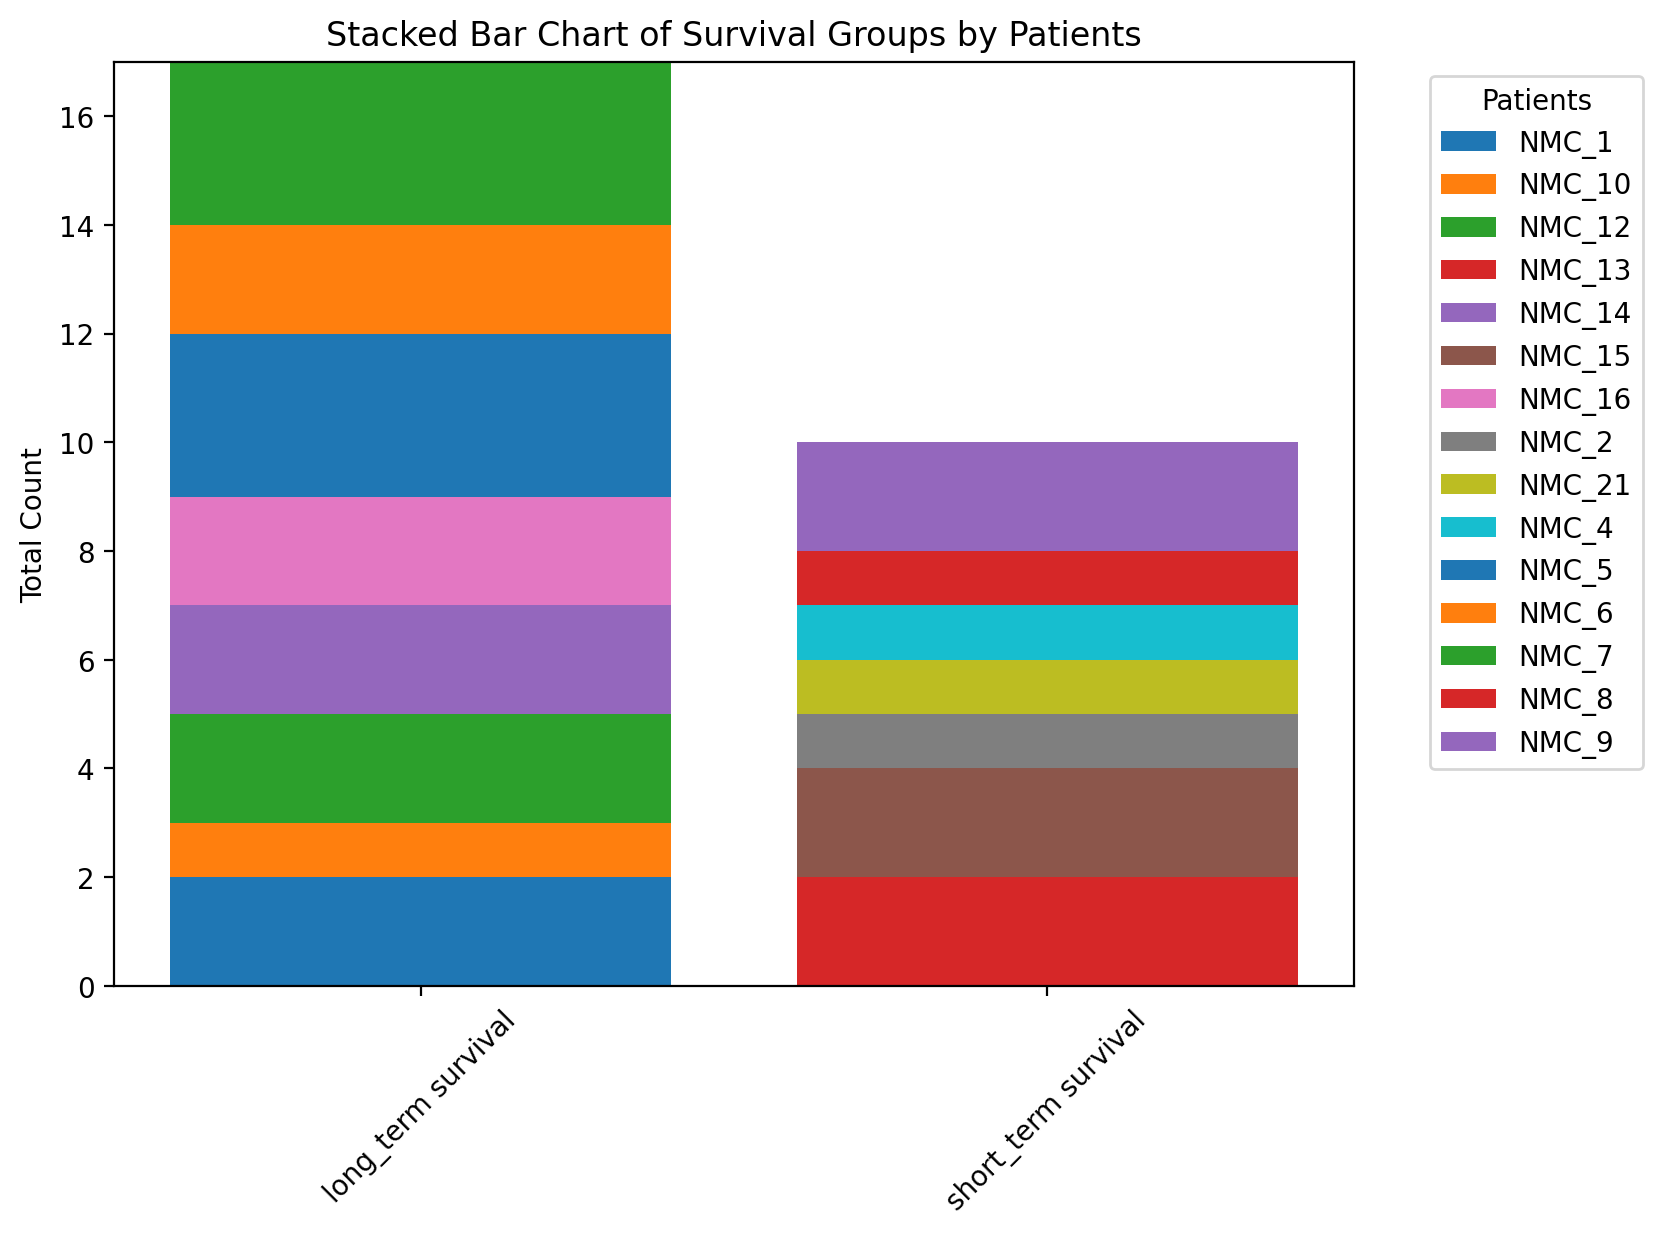

In [14]:
#barchart based on the outcome_group total number, divided by patients.
outcome_group_count = patients_metadata.groupby(['outcome_group', "patient_ID"]).size().reset_index(name='count')
pivot_df = outcome_group_count.pivot(index="patient_ID", columns="outcome_group", values="count").fillna(0)

#/ Get unique survival groups
survival_groups = pivot_df.columns

# Initialize figure
fig, ax = plt.subplots(figsize=(8, 6))

# Stack the bars for each survival group
bottoms = {group: np.zeros(len(survival_groups)) for group in survival_groups}

for i, patient in enumerate(pivot_df.index):
    values = pivot_df.loc[patient]
    ax.bar(survival_groups, values, label=patient, bottom=bottoms[survival_groups[0]])
    bottoms[survival_groups[0]] += values

# Labels & legend
ax.set_ylabel("Total Count")
ax.set_title("Stacked Bar Chart of Survival Groups by Patients")
ax.legend(title="Patients", bbox_to_anchor=(1.05, 1), loc="upper left")  # Move legend outside

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


# Check the Cell type Distribution

## Remove the trash cells

In [15]:
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    meta = pd.read_csv(roi / 'metadata.csv')
    if "Trash" not in meta["cell_type"].unique():
        print("No trash cells in metadata")
        continue
    else:
        pass
    print("Removing trash cells")
    meta = meta.loc[meta["cell_type"] != "Trash"]
    exp = exp[exp["cell_id"].isin(meta.cell_id)]
    #export csvs
    exp.to_csv(roi / 'exp.csv', index=False)
    meta.to_csv(roi / 'metadata.csv', index=False)

No trash cells in metadata
No trash cells in metadata
Removing trash cells
Removing trash cells
No trash cells in metadata
No trash cells in metadata
Removing trash cells
Removing trash cells
Removing trash cells
Removing trash cells
No trash cells in metadata
No trash cells in metadata
Removing trash cells
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
Removing trash cells
No trash cells in metadata
No trash cells in metadata


## Extract the names of all cell types

In [16]:
# Create a list of all cell types
all_cell_types = []  
for i, roi in enumerate(roi_list):
    meta = pd.read_csv(roi / 'metadata.csv')
    all_cell_types.extend(meta["cell_type"].unique())
# Create a set of unique cell types
all_cell_types = sorted(set(all_cell_types))   
# Create a DataFrame with all cell types and initialize counts to zero
meta = pd.read_csv(roi_list[0] / 'metadata.csv')
meta_counts = meta["cell_type"].value_counts()
for cell_type in all_cell_types:
        if cell_type not in meta_counts:
            meta_counts[cell_type] = 0
sorted_order = meta_counts.index  # Extract the index order from a reference DataFrame
all_cell_types = list(sorted_order)
all_cell_types

['Tumor_cells',
 'Actin+_cells',
 'NFC',
 'Endothelial_cells',
 'CD4+_T_cells',
 'M1_macrophages',
 'DCs',
 'M1_M2_macrophages',
 'Mast_cells',
 'M2_macrophages',
 'CD8+_T_cells',
 'Treg_T_cells',
 'Plasma_cells',
 'Lymphatic_endothelial_cells',
 'MDSCs',
 'B_cells',
 'Granulocytes',
 'Epithelial_cells',
 'NK_cells']

## Plot cell types distribution

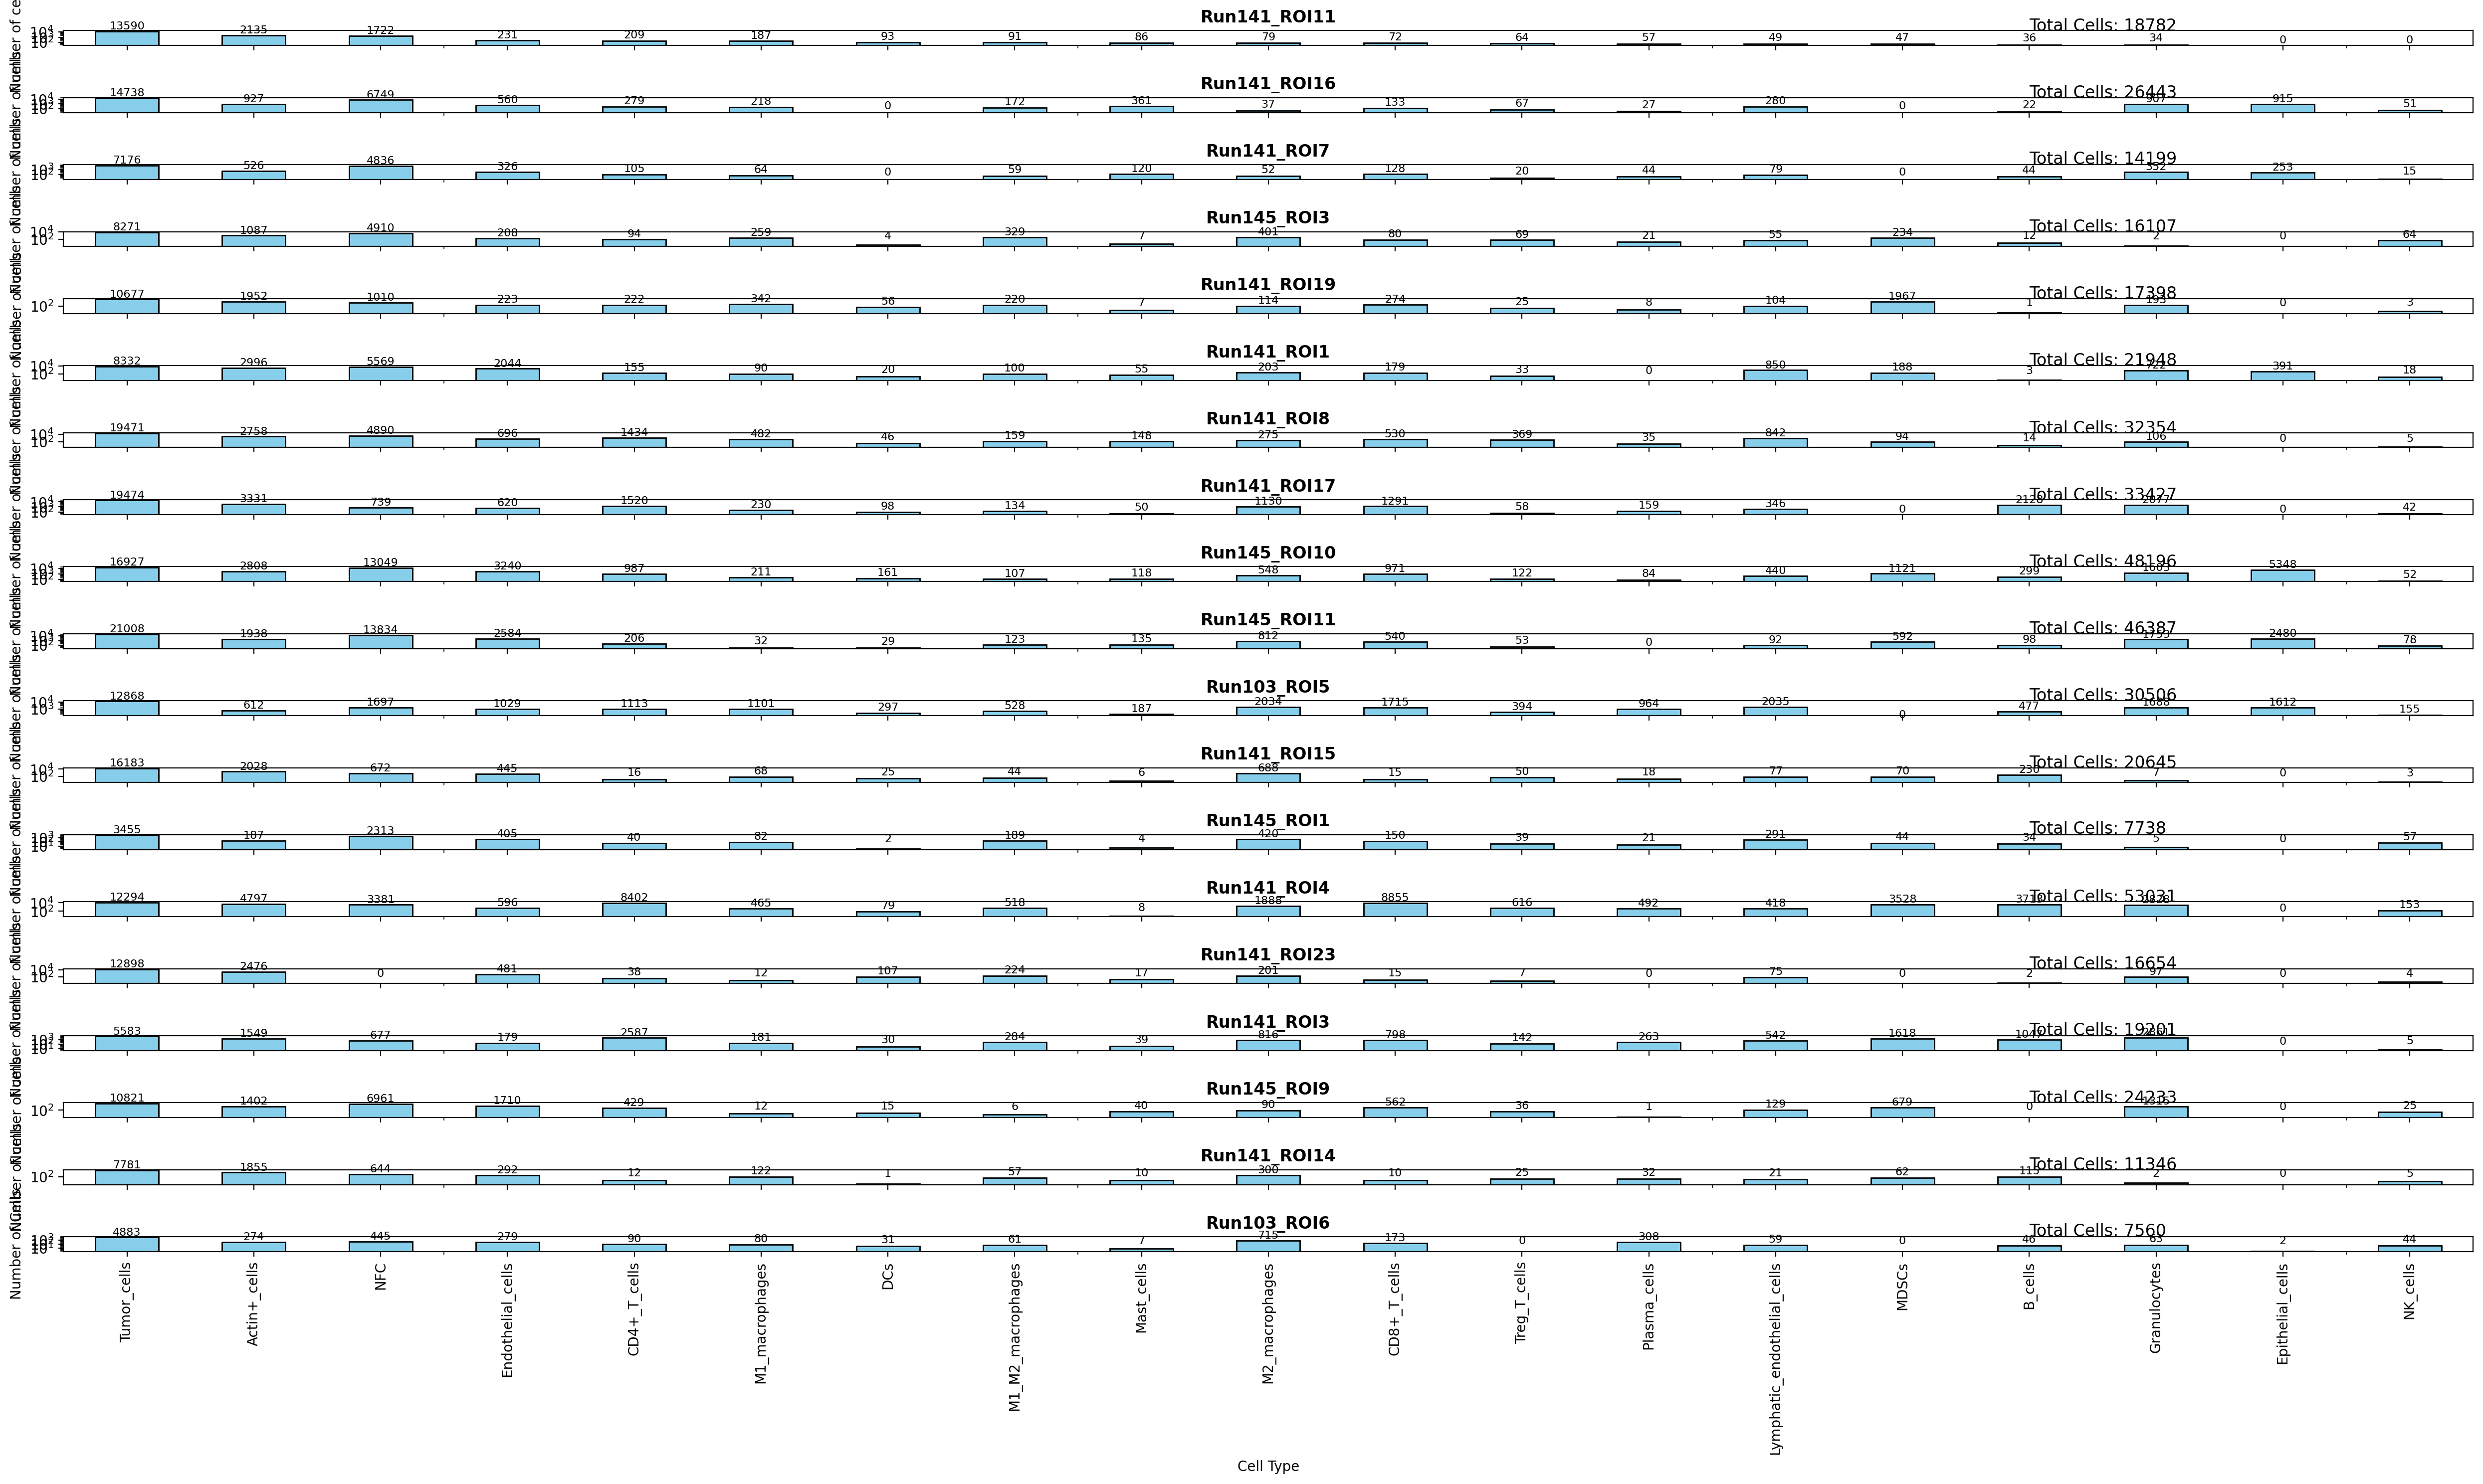

In [17]:
fig, axes = plt.subplots(len(roi_list), 1, figsize=(25, 15), sharex=True)

for i, roi in enumerate(roi_list):
    meta = pd.read_csv(roi / 'metadata.csv')
    meta_counts = meta["cell_type"].value_counts()
    patients_metadata = pd.read_csv(metadata_dir / 'new_patients_metadata.csv')
    #fill cell types with 0 if they are not present in the metadata
    for cell_type in all_cell_types:
        if cell_type not in meta_counts:
            meta_counts[cell_type] = 0
    meta_counts = meta_counts.reindex(all_cell_types)
    #make bar plot with percentages of meta_counts
    meta_counts.plot(kind='bar', ax=axes[i], color = "skyblue", edgecolor='black',)
    axes[i].text(15, np.max(meta_counts) + 5000 , f'Total Cells: {meta_counts.sum()}', fontsize=12)
    #add the number of cells in each cell type on the bar
    for j, count in enumerate(meta_counts):
        axes[i].text(j, count + 30, count, ha='center', va='bottom', fontsize=8)
    axes[i].set_title(f"{roi.name}", fontweight='bold')
    axes[i].set_ylabel('Number of cells')
    #log transform the y-axis
    axes[i].set_yscale('log')
    #make font size of y axis label smaller
axes[-1].set_xticks(range(len(all_cell_types)))
axes[-1].set_xticklabels(all_cell_types, rotation=90)
axes[i].set_xlabel("Cell Type")
axes[i].set_ylabel("Number of Cells")
fig.tight_layout()

In [18]:
#Plot the cell types percentages across all ROIs
all_meta_counts = []
for roi in roi_list:
    meta = pd.read_csv(roi / 'metadata.csv')
    meta_counts = meta["cell_type"].value_counts()
    #fill cell types with 0 if they are not present in the metadata
    for cell_type in all_cell_types:
        if cell_type not in meta_counts:
            meta_counts[cell_type] = 0
    meta_counts = meta_counts.reindex(all_cell_types)
    #Create a dataframe with the ROI names
    meta_counts = meta_counts.to_frame().reset_index()
    counts_sum = meta_counts["count"].sum()
    meta_counts["percentage"] = meta_counts["count"] / counts_sum * 100
    meta_counts["roi"] = roi.name
    all_meta_counts.append(meta_counts)

all_meta_counts = pd.concat(all_meta_counts)

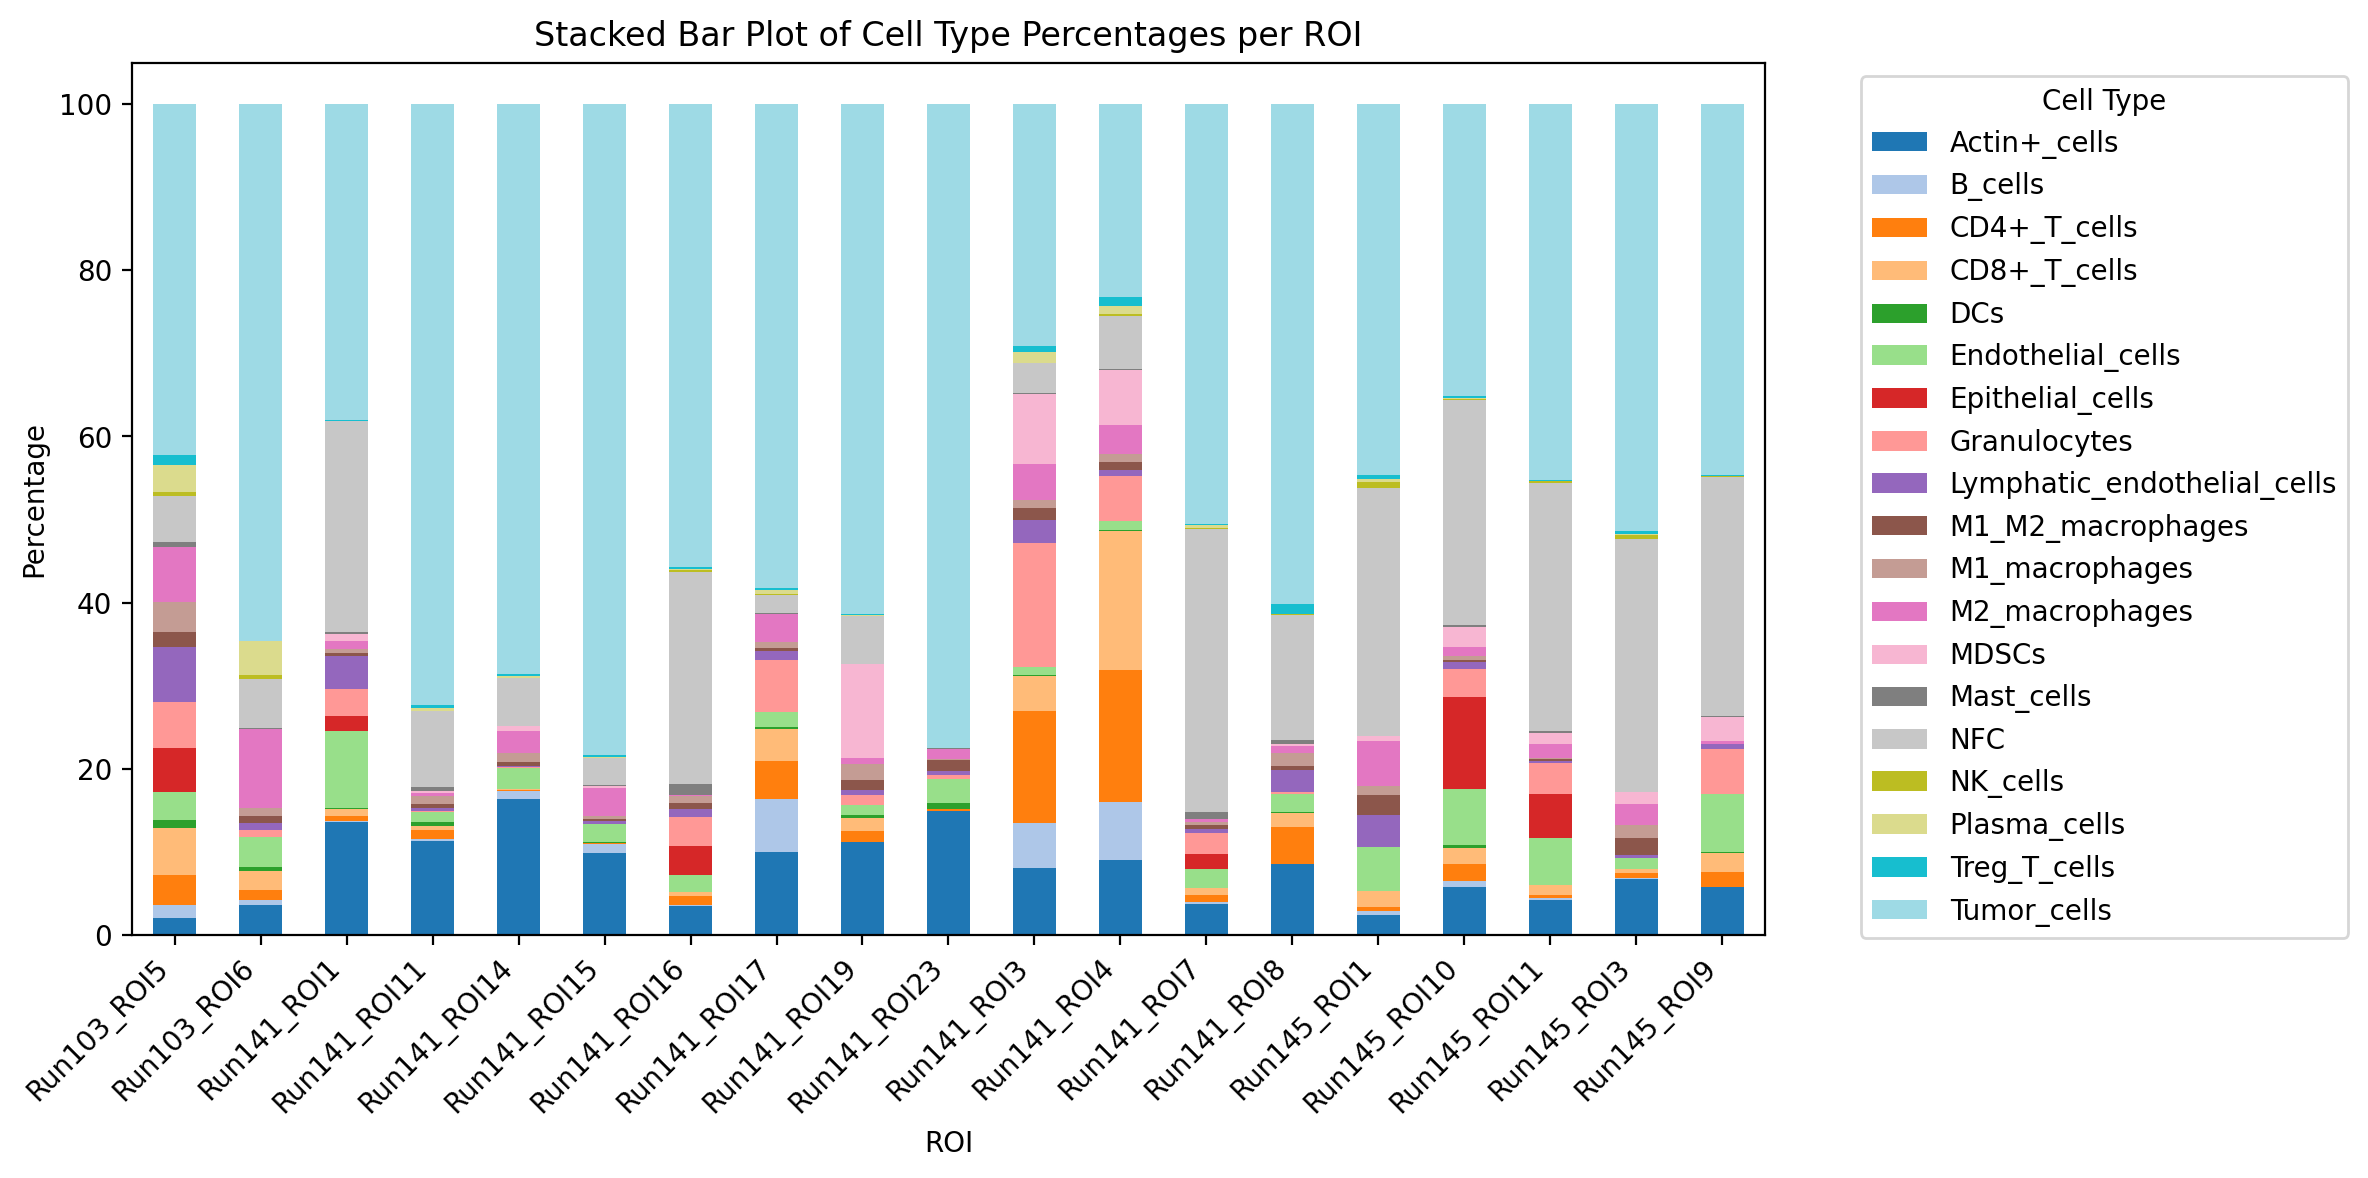

In [19]:
df_pivot = all_meta_counts.pivot(index="roi", columns="cell_type", values="percentage").fillna(0)

# Plotting
ax = df_pivot.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab20")

# Labels and formatting
plt.ylabel("Percentage")
plt.xlabel("ROI")
plt.title("Stacked Bar Plot of Cell Type Percentages per ROI")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Show plot
plt.show()

## Checking if the number of antibodies is equal in all datasets

In [20]:
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    print(len(exp.columns))

49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49


## Plotting the histograms of the lowly expressed markers

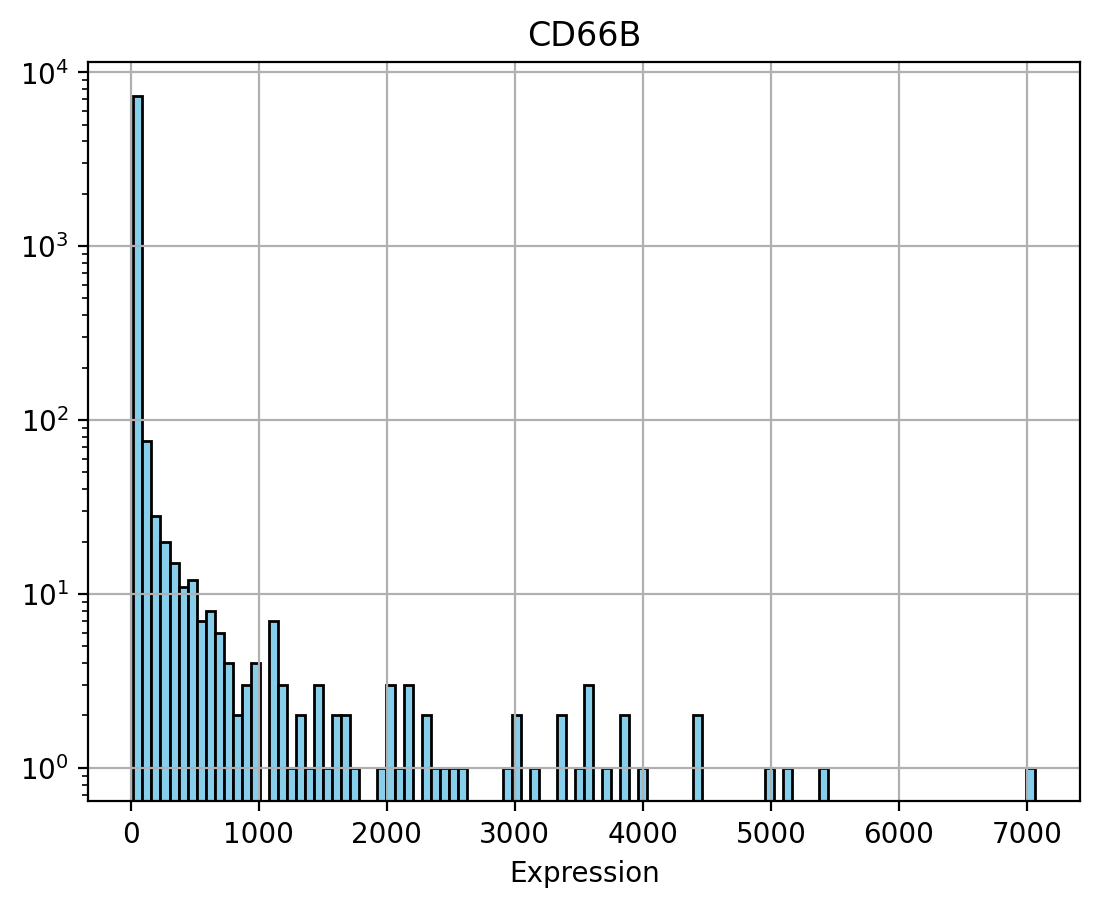

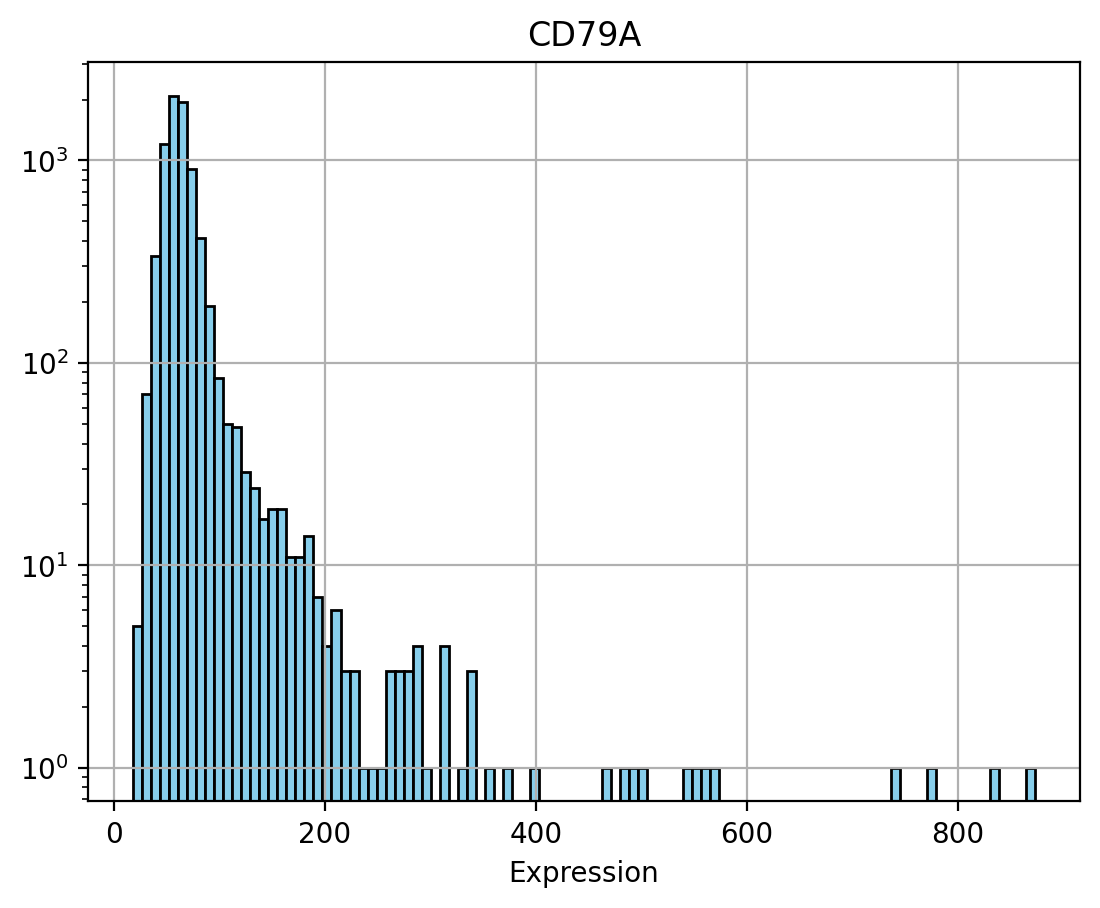

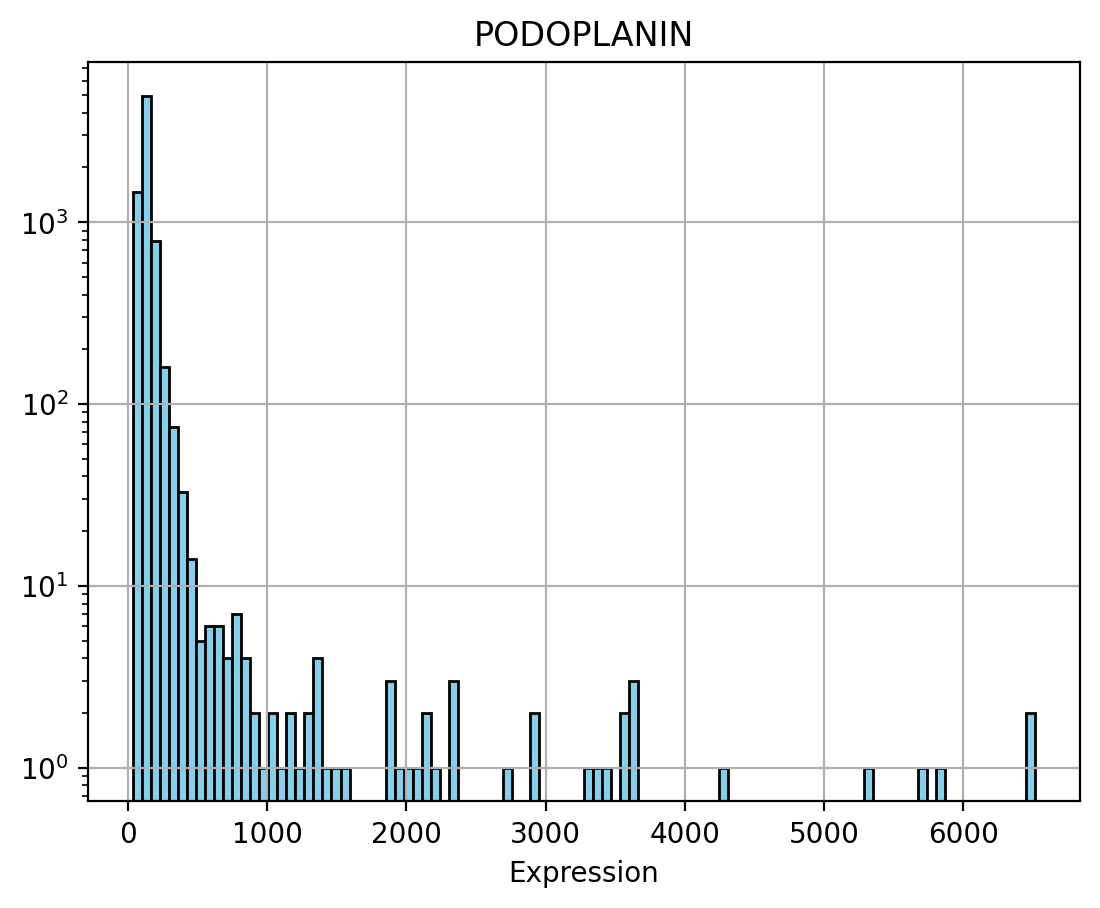

In [21]:
all_exp = []
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    exp.drop(columns=["cell_id"], inplace=True)
    exp = exp.median(axis=0).to_frame().T
    exp.insert(0, "exp_name", roi.name)
    all_exp.append(exp)
all_exp = pd.concat(all_exp, ignore_index=True)
all_exp_mean = all_exp.iloc[:,1:].median(axis=0)
lowly_antibodies = all_exp_mean[all_exp_mean < 50].index

exp = pd.read_csv(roi / 'exp.csv')
for marker in lowly_antibodies:
    exp[marker].hist(bins=100, color='skyblue', edgecolor='black', log=True)
    plt.title(marker)
    plt.xlabel('Expression')
    plt.show()

## Find duplicated antibodies (different dilutation factors)

In [51]:
#Identify duplicated antibodies
duplicated_abs = ["P16", "CD274", "TIM3"]

## Plot the correlation between the antibody intensity and its diluted version

IndexError: single positional indexer is out-of-bounds

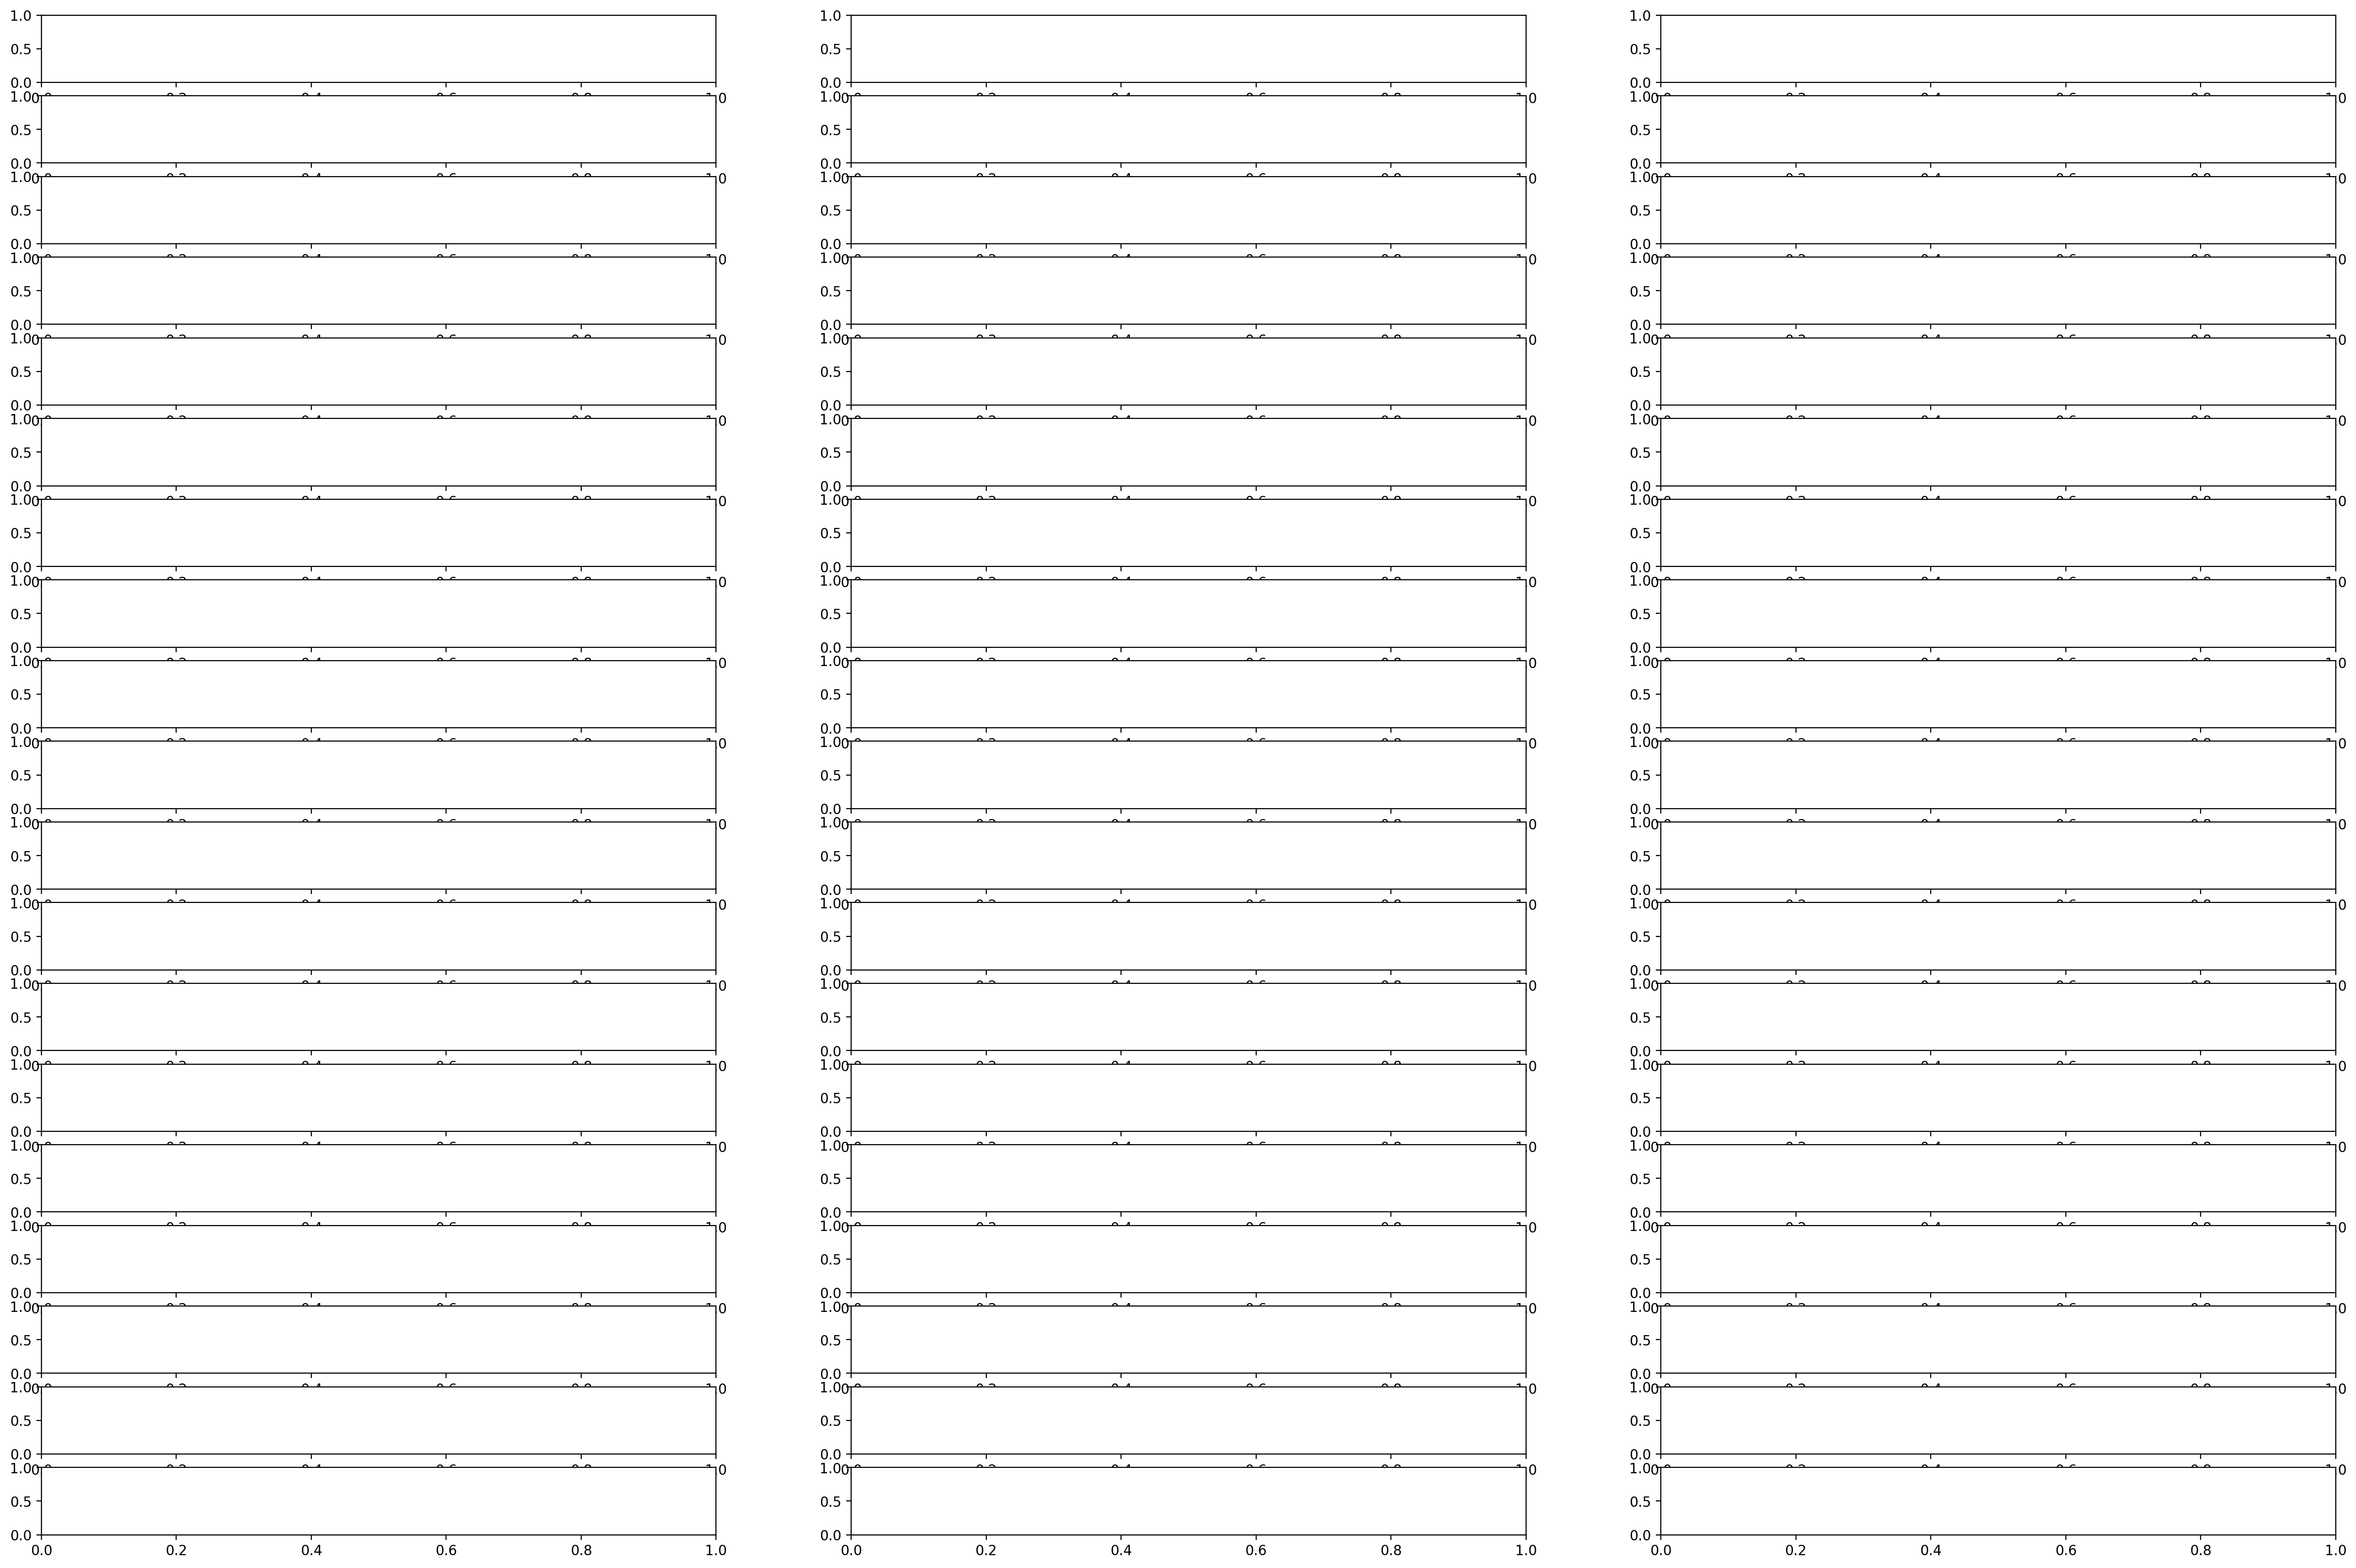

In [52]:
fig, axes = plt.subplots(len(roi_list), len(duplicated_abs), figsize=(30, 20))

for i, roi in enumerate(roi_list):
    exp = pd.read_csv(roi / 'exp.csv')
    for j, marker in enumerate(duplicated_abs):
        exp_filter = exp.filter(like = marker)
        x = exp_filter.iloc[:,0]
        y = exp_filter.iloc[:,1]
        axes[i,j].scatter(x, y, color='skyblue')
        b, a = np.polyfit(x, y, deg=1)    
        axes[i,j].plot(x, a + b * x, color="k")
        #calculate linear correlation coefficient and add it to the plot
        corr = np.corrcoef(x, y)[0,1]
        axes[i,j].text(0.2, 0.9, "r = {:.2f}".format(corr), transform=axes[i,j].transAxes)
        axes[i,j].set_title(marker)

fig.tight_layout()

In [177]:
# Build a heatmap for the correlation
# Build the correlation dataframe
corr_df = []
for marker in duplicated_abs:
    corrs = {}
    for roi in roi_list:
        exp = pd.read_csv(roi / 'exp.csv')
        exp_filter = exp.filter(like = marker)
        x = exp_filter.iloc[:,0]
        y = exp_filter.iloc[:,1]
        cor = np.corrcoef(x, y)[0,1]
        corrs[roi.name] = cor
    corr_df1 = pd.DataFrame.from_dict(corrs, orient='index', columns=[marker])
    corr_df.append(corr_df1)
corr_df = pd.concat(corr_df, axis=1)    

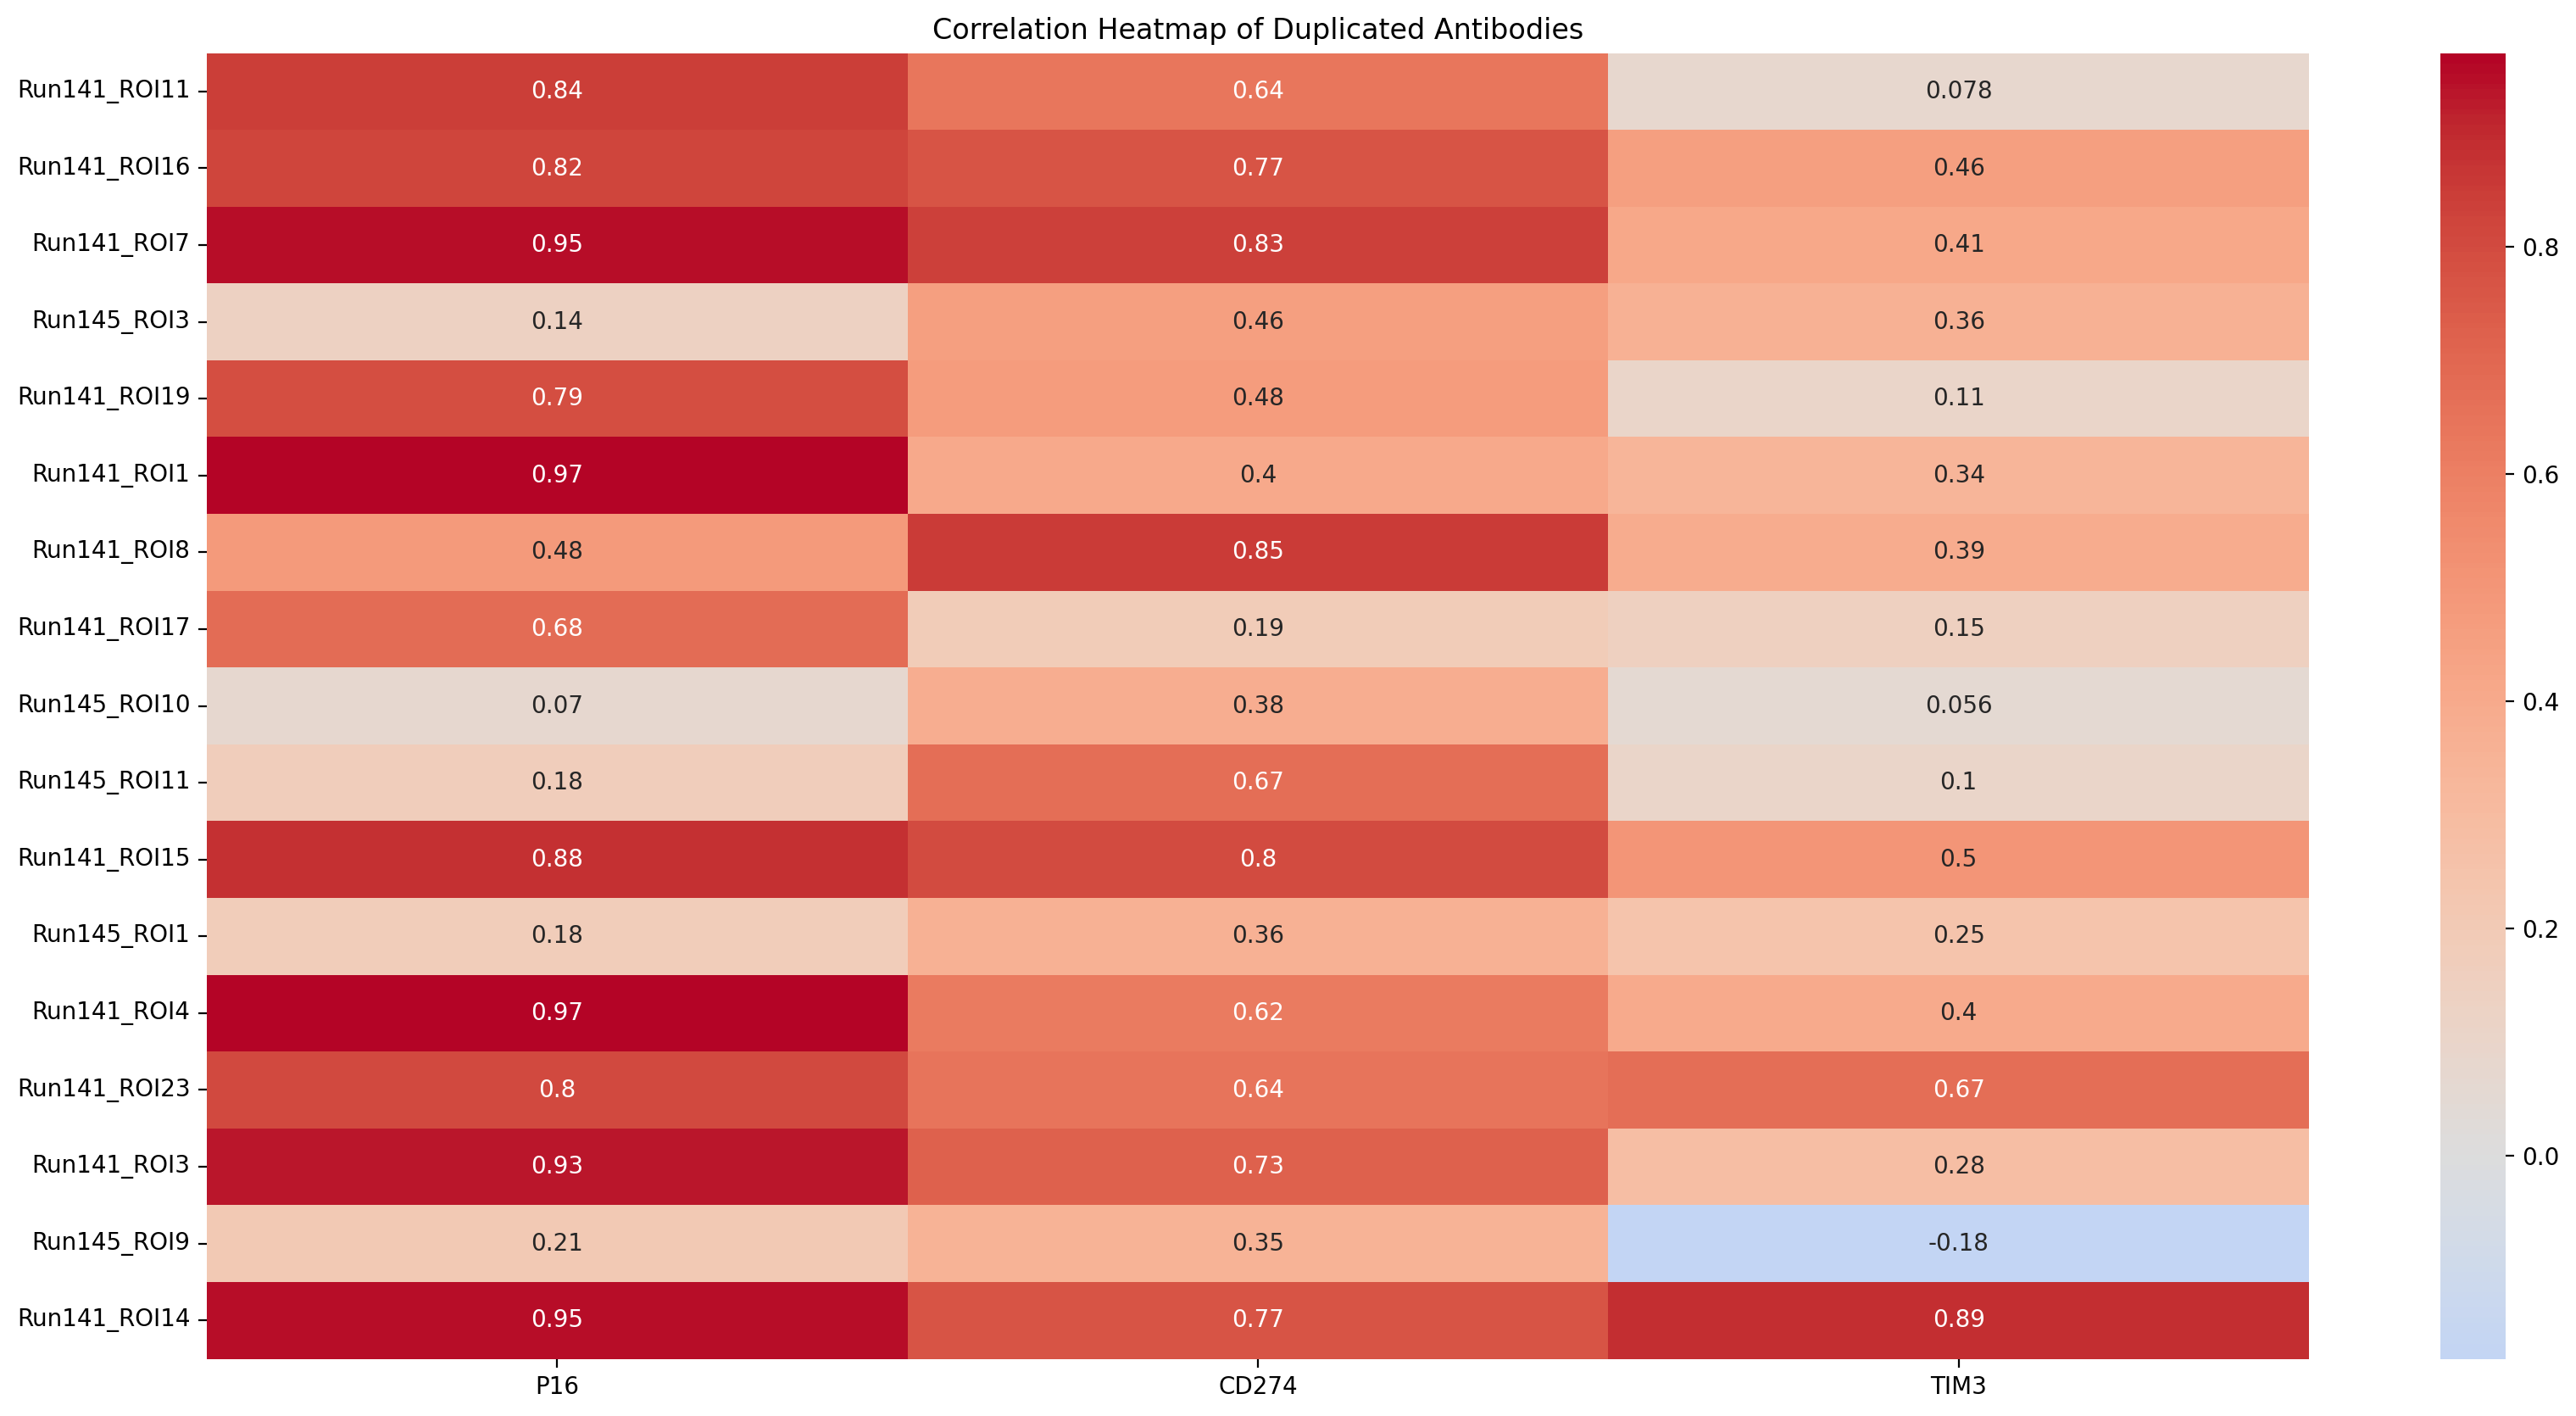

In [178]:
#Build the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Duplicated Antibodies")
plt.show()

## Averaging the duplicates

In [179]:
#let's average the expression of the duplicated antibodies
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    for marker in duplicated_abs:
        exp_filter = exp.filter(like = marker)
        exp = exp.loc[:, ~exp.columns.str.contains(marker)]
        exp[marker] = exp_filter.mean(axis=1)
    exp.to_csv(roi / 'exp.csv', index=False)